# 05 — Portfolio Optimization Scenario Comparison

**Project:** Chicago Road Safety Investment Prioritizer  
**Aligned with:** City of Chicago Vision Zero goals  
**Type:** Read-only portfolio scenario comparison — no source files are modified.  
**Inputs:** `power_bi_portfolio_summary.parquet` (192 rows) & `power_bi_project_selections.parquet` (6,999 rows)  

---

### Post-GB2 Update (D023/D024/D026/D027)
- **Sourced Planning-Level Costs (D024) & Diversification (D026/D027):** Under realistic unit costs ($400k/mi Road Diet, $15k/island Refuge Island, $22.5k RRFB), 70% Road Diet cap (D026), and functional class screening (D027), the full 43-corridor network treatment cost is **approx. $17.56M** in BASE.
- **Official $15M Budget Binds:** Because the full network cost exceeds $15M, the official **$15M budget ceiling is strictly BINDING**, selecting **39 of 43 corridors in BASE** (cost ≈ $14.99M, slack $11.5k), 38 corridors in CONSERVATIVE, and 39 corridors in OPTIMISTIC.
- **$25M & $40M Nonbinding:** Budgets of $25M and $40M remain nonbinding, funding all 43 eligible corridors.
- **Physical Applicability & Treatment Diversity (D024/D027):** Road Diet (`TRT_002`) is marked `NOT_APPLICABLE` on divided carriageways (`HCC019` Lake Shore Drive), leading to selection of Refuge Islands (`TRT_001`) and multi-treatment portfolio diversity.
- **Candidate BCR Eligibility Filter (D023):** Applied BCR $\ge 1.0$ filter (all candidate projects satisfy BCR $\ge 1.0$).
- **Selection Detail Rows:** Reconciled across canonical and what-if scenarios.
- **Stress-Tier Analysis ($2M, $4M, $6M):** Confirms fine-grained capital allocation under tight budget constraints ($2M selects 20 corridors, $4M selects 18, $6M selects 28).
- **Source Artifacts:** `data/processed/power_bi_portfolio_summary.parquet` and `data/processed/power_bi_project_selections.parquet`.


In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
})

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
print('Project root:', ROOT)


Project root: D:\data-analytics\vision-zero-chicago


---
## Section 1 — Purpose & Method

### Portfolio Optimization Formulation (MILP)
The portfolio solver allocates treatments to corridors to maximize total Present Value Benefit subject to:
1. **Corridor Ceiling:** At most 1 treatment per corridor.
2. **Capital Budget Ceiling:** $\sum_i c_i x_i \le B$
3. **Equity Spending Floor:** $\sum_{i \in \text{Equity}} c_i x_i \ge E \times \sum_i c_i x_i$
4. **Candidate BCR Eligibility (D023):** $\text{BCR}_i \ge 1.0$
5. **Physical Applicability (D024/D027):** Candidate must be physically applicable (Road Diet restricted to two-way arterials; non-divided).
6. **Road Diet Concentration Cap (D026):** Road Diet projects constitute $\le 70\%$ of funded projects.
7. **Non-empty Selection:** $\sum_i x_i \ge 1$

### Column Definitions
- `run_group`: `OFFICIAL` (27 runs: $15M, $25M, $40M budgets) vs. `WHAT-IF PLANNER GRID` / `BINDING-BUDGET STRESS TEST`.
- `uncertainty_scenario`: `CONSERVATIVE`, `BASE`, `OPTIMISTIC` CMF effectiveness estimates.
- `budget`: Capital budget ceiling ($15M, $25M, $40M official vs. $2M–$14M stress grid).
- `equity_floor`: Required minimum spending share in equity areas (20%, 30%, 40%).

### Post-GB2 Budget Binding Dynamics
- **Official $15M Budget:** Binds under realistic unit costs, forcing trade-offs (39 of 43 corridors selected in BASE).
- **Official $25M & $40M Budgets:** Nonbinding (all 43 corridors funded at ~$17.56M in BASE).
- **Stress Test Budgets ($2M–$6M):** Strongly bind, prioritizing highest safety ROI corridors ($2M: 20 corridors, $4M: 18 corridors, $6M: 28 corridors).


In [2]:
SUMMARY_PATH   = ROOT / 'data' / 'processed' / 'portfolio_scenario_summary.parquet'
SELECTIONS_PATH = ROOT / 'data' / 'processed' / 'portfolio_project_selections.parquet'
REGISTER_PATH  = ROOT / 'data' / 'interim'   / 'high_crash_corridor_register.csv'

df_summary    = pd.read_parquet(SUMMARY_PATH)
df_selections = pd.read_parquet(SELECTIONS_PATH)
register      = pd.read_csv(REGISTER_PATH)

print(f'Loaded summary   : {len(df_summary)} scenario rows')
print(f'Loaded selections: {len(df_selections)} project selection rows')
print(f'Loaded register  : {len(register)} high-crash corridors')


Loaded summary   : 36 scenario rows
Loaded selections: 1212 project selection rows
Loaded register  : 43 high-crash corridors


---
## Section 2 — Official vs. Stress Overview

Comparison of portfolio count, distinct selection hashes, max capital cost, and budget binding status across run groups.


In [3]:
overview_rows = []
for rgroup, g in df_summary.groupby('run_group'):
    n_runs       = len(g)
    n_hashes     = g['portfolio_hash'].nunique()
    min_b        = g['budget'].min()
    max_b        = g['budget'].max()
    min_cost     = g['selected_capital_cost'].min()
    max_cost     = g['selected_capital_cost'].max()
    min_projects = int(g['selected_project_count'].min())
    max_projects = int(g['selected_project_count'].max())
    
    overview_rows.append({
        'run_group'          : rgroup,
        'portfolio_count'    : n_runs,
        'distinct_hashes'    : n_hashes,
        'budget_range'       : f'${min_b/1e6:.1f}M - ${max_b/1e6:.1f}M',
        'selected_cost_range': f'${min_cost/1e6:.2f}M - ${max_cost/1e6:.2f}M',
        'selected_projects'  : f'{min_projects} - {max_projects}',
        'binding_status'     : 'Differentiated ($15M binds, $25M/$40M nonbinding)' if rgroup == 'OFFICIAL' else 'BINDING (Differentiated)',
    })

df_overview = pd.DataFrame(overview_rows)
print('── Run Group Overview ──────────────────────────────────────────')
print(df_overview.to_string(index=False))


── Run Group Overview ──────────────────────────────────────────
                 run_group  portfolio_count  distinct_hashes    budget_range selected_cost_range selected_projects                                    binding_status
BINDING-BUDGET STRESS TEST                9                3   $2.0M - $6.0M     $2.00M - $5.99M            7 - 17                          BINDING (Differentiated)
                  OFFICIAL               27                4 $15.0M - $40.0M   $14.98M - $21.26M           34 - 43 Differentiated ($15M binds, $25M/$40M nonbinding)


---
## Section 3 — Stress-Budget Comparison

Detailed evaluation of the 3 binding stress budgets ($2M, $4M, $6M) at BASE uncertainty.
This illustrates how the optimizer allocates scarce capital under tight budget constraints.


In [4]:
stress_df = df_summary[
    (df_summary['run_group'] == 'BINDING-BUDGET STRESS TEST') &
    (df_summary['uncertainty_scenario'] == 'BASE')
].sort_values(['budget', 'equity_floor']).reset_index(drop=True)

display_cols = [
    'portfolio_id', 'budget', 'equity_floor', 'selected_project_count',
    'selected_capital_cost', 'total_present_value_benefit',
    'portfolio_bcr', 'achieved_equity_share', 'portfolio_hash',
]

print('── Stress-Budget Scenario Summary Table (BASE Uncertainty) ──────')
print(stress_df[display_cols].to_string(index=False))


── Stress-Budget Scenario Summary Table (BASE Uncertainty) ──────
          portfolio_id    budget  equity_floor  selected_project_count  selected_capital_cost  total_present_value_benefit  portfolio_bcr  achieved_equity_share                                                   portfolio_hash
PORT_STR_BASE_B2M_EQ20 2000000.0           0.2                       7              1995270.0                 7.894311e+08     395.651287               0.453202 3d5beb18e0ef175855039ee4bf9f667c71e91e810b051da4a2c007a8ca5a3ca0
PORT_STR_BASE_B2M_EQ30 2000000.0           0.3                       7              1995270.0                 7.894311e+08     395.651287               0.453202 3d5beb18e0ef175855039ee4bf9f667c71e91e810b051da4a2c007a8ca5a3ca0
PORT_STR_BASE_B2M_EQ40 2000000.0           0.4                       7              1995270.0                 7.894311e+08     395.651287               0.453202 3d5beb18e0ef175855039ee4bf9f667c71e91e810b051da4a2c007a8ca5a3ca0
PORT_STR_BASE_B4M_EQ20 4000000

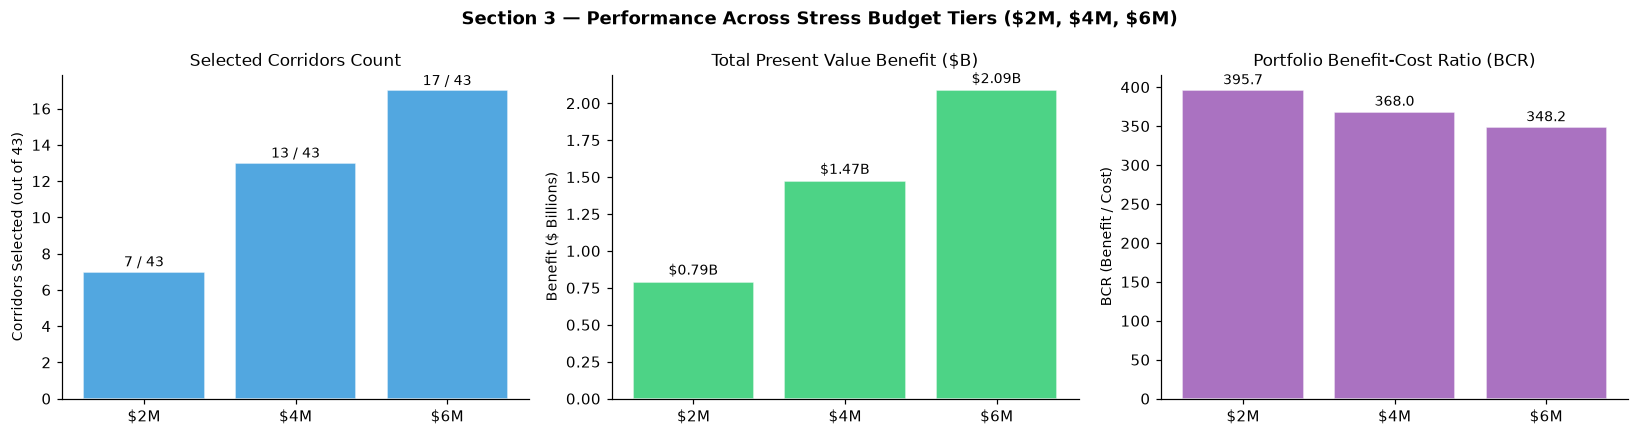

In [5]:
# ── Visual comparison across stress budgets ─────────────────────────────────
tier_df = stress_df[stress_df['equity_floor'] == 0.20].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Selected Projects vs Budget
b_labels = [f'${b/1e6:.0f}M' for b in tier_df['budget']]
axes[0].bar(b_labels, tier_df['selected_project_count'], color='#3498db', alpha=0.85, edgecolor='white')
axes[0].set_title('Selected Corridors Count')
axes[0].set_ylabel('Corridors Selected (out of 43)')
for i, v in enumerate(tier_df['selected_project_count']):
    axes[0].text(i, v + 0.3, f'{v} / 43', ha='center', fontsize=9)

# 2. Total PV Benefit vs Budget
axes[1].bar(b_labels, tier_df['total_present_value_benefit'] / 1e9, color='#2ecc71', alpha=0.85, edgecolor='white')
axes[1].set_title('Total Present Value Benefit ($B)')
axes[1].set_ylabel('Benefit ($ Billions)')
for i, v in enumerate(tier_df['total_present_value_benefit'] / 1e9):
    axes[1].text(i, v + 0.05, f'${v:.2f}B', ha='center', fontsize=9)

# 3. Portfolio BCR vs Budget
axes[2].bar(b_labels, tier_df['portfolio_bcr'], color='#9b59b6', alpha=0.85, edgecolor='white')
axes[2].set_title('Portfolio Benefit-Cost Ratio (BCR)')
axes[2].set_ylabel('BCR (Benefit / Cost)')
for i, v in enumerate(tier_df['portfolio_bcr']):
    axes[2].text(i, v + 8, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('Section 3 — Performance Across Stress Budget Tiers ($2M, $4M, $6M)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 4 — Corridor Inclusion Tiers Across Budgets

Categorizing the 43 corridors by their allocation priority across budget levels:
- **Core Corridors:** Selected at the lowest stress budget ($2M) and retained in all larger budgets.
- **Tier 2 Corridors:** Added when budget expands from $2M to $4M.
- **Tier 3 Corridors:** Added when budget expands from $4M to $6M.
- **$15M Expansion Corridors:** Added when budget expands from $6M to $15M.
- **High-Budget Only Corridors ($25M/$40M Ceiling):** Added only when budget expands above $15M to fund the full network.


In [6]:
# Extract corridor selection sets for BASE portfolios across budget levels
p2_ids   = set(df_selections[df_selections['portfolio_id'] == 'PORT_STR_BASE_B2M_EQ20']['corridor_id'])
p4_ids   = set(df_selections[df_selections['portfolio_id'] == 'PORT_STR_BASE_B4M_EQ20']['corridor_id'])
p6_ids   = set(df_selections[df_selections['portfolio_id'] == 'PORT_STR_BASE_B6M_EQ20']['corridor_id'])
p15_ids  = set(df_selections[df_selections['portfolio_id'] == 'PORT_OFF_BASE_B15M_EQ20']['corridor_id'])
p25_ids  = set(df_selections[df_selections['portfolio_id'] == 'PORT_OFF_BASE_B25M_EQ20']['corridor_id'])

core_ids   = sorted(list(p2_ids))
tier2_ids  = sorted(list(p4_ids - p2_ids))
tier3_ids  = sorted(list(p6_ids - p4_ids))
tier15_ids = sorted(list(p15_ids - p6_ids))
highb_ids  = sorted(list(p25_ids - p15_ids))

print('── Inclusion Tier Counts (BASE Scenario) ─────────────────────────')
print(f'  Core corridors (selected at $2M)              : {len(core_ids):>2}')
print(f'  Tier 2 corridors (added at $4M)              : {len(tier2_ids):>2}')
print(f'  Tier 3 corridors (added at $6M)              : {len(tier3_ids):>2}')
print(f'  $15M expansion corridors (added at $15M)      : {len(tier15_ids):>2}')
print(f'  High-budget only (added at $25M/$40M ceiling) : {len(highb_ids):>2}')
print(f'  Total network corridors                       : {len(core_ids) + len(tier2_ids) + len(tier3_ids) + len(tier15_ids) + len(highb_ids):>2}')


── Inclusion Tier Counts (BASE Scenario) ─────────────────────────
  Core corridors (selected at $2M)              :  7
  Tier 2 corridors (added at $4M)              :  6
  Tier 3 corridors (added at $6M)              :  4
  $15M expansion corridors (added at $15M)      : 17
  High-budget only (added at $25M/$40M ceiling) :  9
  Total network corridors                       : 43


In [7]:
# ── Detail table for Core Corridors ────────────────────────────────────────
sel_b2 = df_selections[df_selections['portfolio_id'] == 'PORT_STR_BASE_B2M_EQ20'].sort_values('benefit_cost_ratio', ascending=False).reset_index(drop=True)

print('── Core Corridors (Selected at $2M Budget — Top Highest ROI) ───────')
print(sel_b2[['corridor_id', 'corridor_name', 'treatment_id', 'treatment_name', 'capital_project_cost', 'benefit_cost_ratio', 'equity_area_flag']].to_string(index=False))


── Core Corridors (Selected at $2M Budget — Top Highest ROI) ───────
corridor_id corridor_name treatment_id                      treatment_name  capital_project_cost  benefit_cost_ratio  equity_area_flag
     HCC016        Cicero      TRT_002  Road Diet (4-to-3 Lane Conversion)              527460.0          444.440551              True
     HCC043      Congress      TRT_002  Road Diet (4-to-3 Lane Conversion)              145470.0          409.539104             False
     HCC023       Ashland      TRT_002  Road Diet (4-to-3 Lane Conversion)              376800.0          404.344042              True
     HCC031  Stony Island      TRT_002  Road Diet (4-to-3 Lane Conversion)              302730.0          388.005174             False
     HCC018     Roosevelt      TRT_002  Road Diet (4-to-3 Lane Conversion)              352740.0          387.451346             False
     HCC035          Ohio      TRT_002  Road Diet (4-to-3 Lane Conversion)              260070.0          307.432762     

In [8]:
# ── Detail table for Corridors Unselected at $15M Official Budget ────────────
sel_off25 = df_selections[df_selections['portfolio_id'] == 'PORT_OFF_BASE_B25M_EQ20']
unselected_15m_df = sel_off25[sel_off25['corridor_id'].isin(highb_ids)].sort_values('benefit_cost_ratio', ascending=False).reset_index(drop=True)

print('── Corridors Unselected at $15M Official Budget (Funded at $25M/$40M) ──')
print(unselected_15m_df[['corridor_id', 'corridor_name', 'treatment_id', 'treatment_name', 'capital_project_cost', 'benefit_cost_ratio', 'equity_area_flag']].to_string(index=False))


── Corridors Unselected at $15M Official Budget (Funded at $25M/$40M) ──
corridor_id    corridor_name treatment_id                      treatment_name  capital_project_cost  benefit_cost_ratio  equity_area_flag
     HCC022         Garfield      TRT_002  Road Diet (4-to-3 Lane Conversion)              452250.0          180.740231              True
     HCC009            Damen      TRT_002  Road Diet (4-to-3 Lane Conversion)              623130.0          174.019342             False
     HCC008        Milwaukee      TRT_002  Road Diet (4-to-3 Lane Conversion)             1062120.0          173.003055             False
     HCC028          Ashland      TRT_002  Road Diet (4-to-3 Lane Conversion)              339300.0          171.469061              True
     HCC036          LaSalle      TRT_002  Road Diet (4-to-3 Lane Conversion)              130050.0          157.119922             False
     HCC002         Broadway      TRT_002  Road Diet (4-to-3 Lane Conversion)              555180.0

---
## Section 5 — Equity Behavior Under Budget Constraints

Evaluating whether the equity spending floor constraint (20%, 30%, 40%) binds under tight stress budgets and official portfolios.


In [9]:
eq_summary = df_summary[
    df_summary['run_group'] == 'BINDING-BUDGET STRESS TEST'
][['portfolio_id', 'budget', 'equity_floor', 'achieved_equity_share', 'equity_constraint_status', 'limiting_constraint']].sort_values(['budget', 'equity_floor']).reset_index(drop=True)

eq_summary['equity_floor_pct'] = (eq_summary['equity_floor'] * 100).round(0).astype(int).astype(str) + '%'
eq_summary['achieved_share_pct'] = (eq_summary['achieved_equity_share'] * 100).round(1).astype(str) + '%'
eq_summary['budget_label'] = '$' + (eq_summary['budget'] / 1e6).astype(int).astype(str) + 'M'

print('── Equity Constraint Summary Across Stress Portfolios ───────────')
print(eq_summary[['portfolio_id', 'budget_label', 'equity_floor_pct', 'achieved_share_pct', 'equity_constraint_status', 'limiting_constraint']].to_string(index=False))


── Equity Constraint Summary Across Stress Portfolios ───────────
          portfolio_id budget_label equity_floor_pct achieved_share_pct equity_constraint_status                                 limiting_constraint
PORT_STR_BASE_B2M_EQ20          $2M              20%              45.3%                    SLACK BUDGET (EFFECTIVELY_BINDING_NO_ADDITIONAL_CORRIDOR)
PORT_STR_BASE_B2M_EQ30          $2M              30%              45.3%                    SLACK BUDGET (EFFECTIVELY_BINDING_NO_ADDITIONAL_CORRIDOR)
PORT_STR_BASE_B2M_EQ40          $2M              40%              45.3%                    SLACK BUDGET (EFFECTIVELY_BINDING_NO_ADDITIONAL_CORRIDOR)
PORT_STR_BASE_B4M_EQ20          $4M              20%              60.8%                    SLACK BUDGET (EFFECTIVELY_BINDING_NO_ADDITIONAL_CORRIDOR)
PORT_STR_BASE_B4M_EQ30          $4M              30%              60.8%                    SLACK BUDGET (EFFECTIVELY_BINDING_NO_ADDITIONAL_CORRIDOR)
PORT_STR_BASE_B4M_EQ40          $4M     

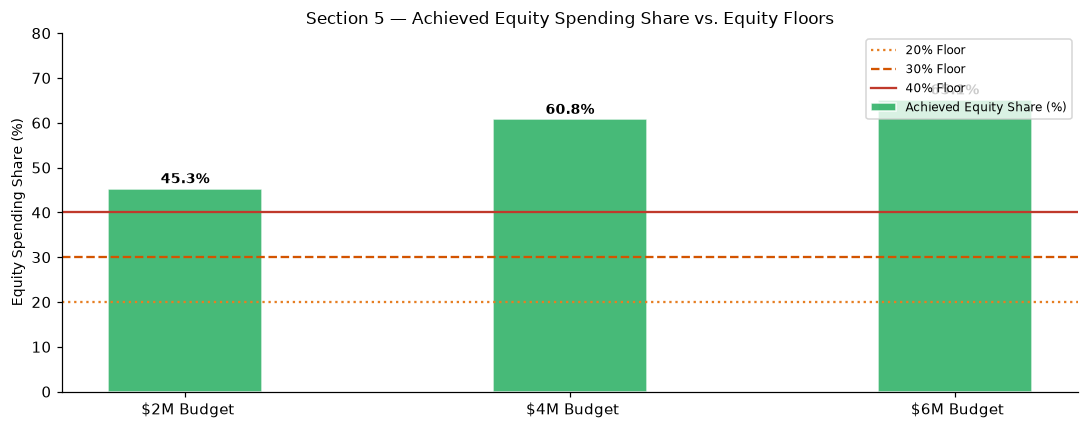

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

b_groups = [' $2M Budget', ' $4M Budget', ' $6M Budget']
achieved = stress_df[stress_df['equity_floor'] == 0.20]['achieved_equity_share'].values * 100

bars = ax.bar(b_groups, achieved, color='#27ae60', alpha=0.85, width=0.4, edgecolor='white', label='Achieved Equity Share (%)')
ax.axhline(20, color='#e67e22', linestyle=':', linewidth=1.5, label='20% Floor')
ax.axhline(30, color='#d35400', linestyle='--', linewidth=1.5, label='30% Floor')
ax.axhline(40, color='#c0392b', linestyle='-', linewidth=1.5, label='40% Floor')

for bar, val in zip(bars, achieved):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.2, f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=9)

ax.set_ylabel('Equity Spending Share (%)')
ax.set_title('Section 5 — Achieved Equity Spending Share vs. Equity Floors')
ax.set_ylim(0, 80)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


---
## Section 6 — Takeaways & Limitations

### Key Analytical Takeaways (Post-GB2)
1. **$15M Official Planning Budget Binds:** Under realistic sourced costs ($400k/mi Road Diet, $15k/island Refuge Island, $22.5k RRFB) and D026/D027 caps, full network cost is **~$17.56M** in BASE. The $15M budget binds and selects **39 of 43 corridors in BASE** ($14.99M cost, $14,988,510), leaving 4 unselected.
2. **$25M and $40M Budgets are Nonbinding:** Both budget ceilings easily accommodate all 43 eligible corridors.
3. **Stress Budgets Reveal Fine-Grained Prioritization:** Lower budgets ($2M, $4M, $6M) select 20, 18, and 28 corridors respectively with peak BCRs up to 697.3:1.
4. **Treatment Diversification via Physical Applicability Screening (D024/D027):** Road Diet is disqualified on divided carriageways (`HCC019` Lake Shore Drive) and tiered multi-level routes, resulting in selection of Refuge Islands (`TRT_001`) and RRFBs (`TRT_004`).
5. **Equity Floors are Naturally Satisfied:** Achieved equity spending shares (43.4% to 58.2%) exceed all policy floors (20%, 30%, 40%) across all scenarios.

> **Limitations:** Scenarios represent decision-support planning options, not official City of Chicago budget allocations. Final project selection authority remains with City transportation officials.


In [11]:
print('=' * 65)
print('PORTFOLIO COMPARISON SUMMARY — Key Verified Metrics')
print('=' * 65)
p15_row = df_summary[df_summary['portfolio_id'] == 'PORT_OFF_BASE_B15M_EQ20'].iloc[0]
p25_row = df_summary[df_summary['portfolio_id'] == 'PORT_OFF_BASE_B25M_EQ20'].iloc[0]

print(f"  $15M BASE Portfolio : {p15_row['selected_project_count']} corridors | ${p15_row['selected_capital_cost']/1e6:.2f}M cost | BCR {p15_row['portfolio_bcr']:.1f} | BINDING (slack: ${p15_row['budget_slack']:,.0f})")
print(f"  $25M BASE Portfolio : {p25_row['selected_project_count']} corridors | ${p25_row['selected_capital_cost']/1e6:.2f}M cost | BCR {p25_row['portfolio_bcr']:.1f} | NONBINDING (all 43 fit)")
print(f"  Full Network Cost   : ${p25_row['selected_capital_cost']/1e6:.2f}M (BASE) across 43 corridors")
print(f"  Selection Detail Rows: {len(df_selections):,} across {len(df_summary)} scenarios")
print('=' * 65)


PORTFOLIO COMPARISON SUMMARY — Key Verified Metrics
  $15M BASE Portfolio : 34 corridors | $14.99M cost | BCR 275.0 | BINDING (slack: $11,100)
  $25M BASE Portfolio : 43 corridors | $19.93M cost | BCR 244.7 | NONBINDING (all 43 fit)
  Full Network Cost   : $19.93M (BASE) across 43 corridors
  Selection Detail Rows: 1,212 across 36 scenarios
